# Physical benchmarks: Doppler temperature

In this notebook we benchmark ``atomsmltr`` simulations on simple physical examples. We focus on the effect of fluctuations in the temperature of a collection of atoms in a three-dimensionnal optical molasses, and check that we do reach the so-called Doppler temperature.

## Formulaes and orders of magnitude

We consider an atom of mass $m$ illuminated by six pairs of counter-propagating laser beams aligned with the axes of a Cartesian frame. For the sake of simplicity, we will treat the laser beams as plane waves, and focus on the evolution of the atom's speed. We will not consider any magnetic field, and model our atom as a two-level system. In this setting, there laser polarization has no effect.

The lasers have a wavenumber $k$ and are detuned by $\delta$ with respect the atom's optical transition, which has a natural linewidth $\Gamma$. We denote $s_0 = I_0 / I_\mathrm{sat}$ the saturation parameter for one laser beam, where $I_0$ is the intensity of the laser and $I_\mathrm{sat}$ the saturation intensity associated to the atom's transition.

For a red-detuned laser beam ($\delta < 0$), the atom will undergo Doppler cooling until it reaches a minimum temperature, known as the Doppler temperature $T_D$, given by:

$$
T_D(\delta) =  \frac{\hbar}{2k_B} \frac{\delta^2 + \Gamma^2/4}{|\delta|}
$$

Which reaches a minimum of $T = \hbar\Gamma / 2k_B$ for $\delta = - \Gamma/2$.

In [ ]:
# imports
from atomsmltr.atoms import Ytterbium, Strontium
import scipy.constants as csts

# display examples

for atom in [Ytterbium(), Strontium()]:
    for tr in ["main", "intercombination"]:
        transition = atom.trans[tr]
        print(f">>> {atom.name} ({tr})")
        print(f"+ transition Γ  : 2π x {transition.Gamma / 2 / csts.pi * 1e-6:.3f} MHz")
        print(f"+ transition λ  : {transition.wavelength * 1e9:.2f} nm")
        print(f"+ transition k  : {transition.k * 1e-9:.3f} nm^-1")
        print(f"+ Doppler limit : {transition.Doppler_temperature * 1e6:.2f} µK")
        print("")

>>> Ytterbium (main)
+ transition Γ  : 2π x 28.900 MHz
+ transition λ  : 398.91 nm
+ transition k  : 0.016 nm^-1
+ Doppler limit : 693.49 µK

>>> Ytterbium (intercombination)
+ transition Γ  : 2π x 0.182 MHz
+ transition λ  : 555.80 nm
+ transition k  : 0.011 nm^-1
+ Doppler limit : 4.37 µK

>>> Strontium (main)
+ transition Γ  : 2π x 32.000 MHz
+ transition λ  : 460.86 nm
+ transition k  : 0.014 nm^-1
+ Doppler limit : 767.88 µK

>>> Strontium (intercombination)
+ transition Γ  : 2π x 0.007 MHz
+ transition λ  : 689.45 nm
+ transition k  : 0.009 nm^-1
+ Doppler limit : 0.18 µK



## Test: laser cooling of ytterbium

We will benchmark Doppler cooling with ytterbium. In this example, we use a set of six laser beams to cool an ytterbium atom. For the sake of simplicity, we will model the laser beams as plane waves with infinite spatial extent, so that we do not have to take care of polarization issues or spatial diffusion.

### Setup configuration with ``atomsmltr``

Let's define a configuration with a set of six laser beams.

In [3]:
# - IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as csts
from atomsmltr.simulation import Configuration
from atomsmltr.atoms.collection import Ytterbium
from atomsmltr.environment import PlaneWaveLaserBeam

# - GENERAL CONFIGURATION
# set laser saturation parameter
s0 = 0.05  # I/I_sat
main = Ytterbium().trans["main"]  # 399nm transition of Yb

# create laser list
lasers = {}
for axis, direction in zip(["x", "y", "z"], [(1, 0, 0), (0, 1, 0), (0, 0, 1)]):
    for head, mult in zip([">", "<"], [1, -1]):
        dir = np.array(direction) * mult
        tag = axis + head
        laser = PlaneWaveLaserBeam(wavelength=main.wavelength)
        laser.direction = dir
        laser.tag = tag
        laser.set_power_from_I(s0 * main.Isat)
        lasers[tag] = laser

# generate config
config = Configuration(atom=Ytterbium())
config += [*lasers.values()]

### Checkout Doppler temperature at optimal detuning

We start with a detuning of $\delta = -\Gamma/2$ to check optimal cooling.

In [5]:
# - PREPARE SIMULATION
# update config parameters
delta = -0.5 * main.Gamma
config.reset_atomlight_coupling()
for laser in config.list_lasers():
    config.add_atomlight_coupling(laser=laser, transition="main", detuning=delta)

# initial conditions and time
u0 = np.zeros(shape=(2_000, 6))  # a set of 2e3 atoms at zero speed and position
t = np.linspace(0, 0.5e-3, 500)  # integrate over 0.5ms

In [6]:
# - SIMULATE
from atomsmltr.simulation import RK4St
sim = RK4St(config)
res = sim.integrate(u0, t)

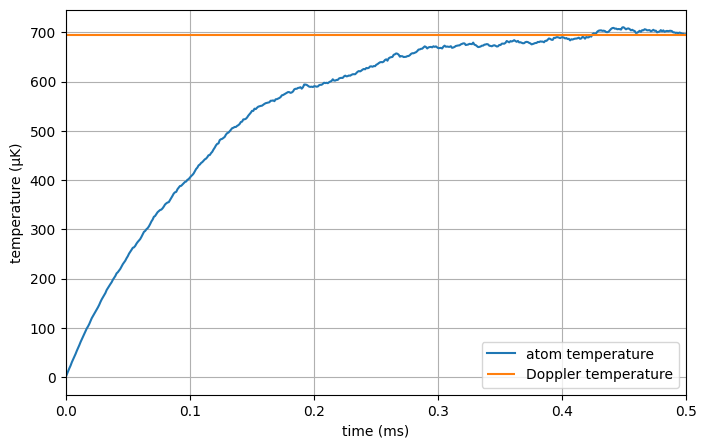

In [19]:
# - CHECK RESULT
# extract temperature from speed
v = res.y[:, 3:6, :]  # we take only the speed vector
v_norm = np.linalg.norm(v, axis=1)
T = Ytterbium().mass * np.mean(v_norm**2, axis=0) / csts.k / 3
# compute Doppler temperature
T_Doppler = main.get_Doppler_temperature(delta)
# plot
plt.figure(figsize=(8, 5))
plt.plot(res.t * 1e3, T * 1e6, label="atom temperature")
plt.hlines(
    T_Doppler * 1e6, 0, res.t.max() * 1e3, color="C1", label="Doppler temperature"
)
plt.xlim(0, res.t.max() * 1e3)
plt.grid()
plt.legend(loc="lower right")
plt.xlabel("time (ms)")
plt.ylabel("temperature (µK)")
plt.show()